In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

df = pd.read_csv('/content/차량_연비_데이터(20022022)_v2.csv')

# 중복값 확인, 제거
print(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

# 결측치 확인
print(df.isnull().sum())

# 'SUV'가 포함된 차량
df_suv = df[df['VEHICLE CLASS'].str.contains('SUV', case=False)].reset_index(drop=True)

42
YEAR               0
MAKE               0
MODEL              0
VEHICLE CLASS      0
ENGINE SIZE        0
CYLINDERS          0
TRANSMISSION       0
FUEL               0
CITY (L/100 km)    0
HWY (L/100 km)     0
COMB (L/100 km)    0
COMB (mpg)         0
EMISSIONS          0
dtype: int64


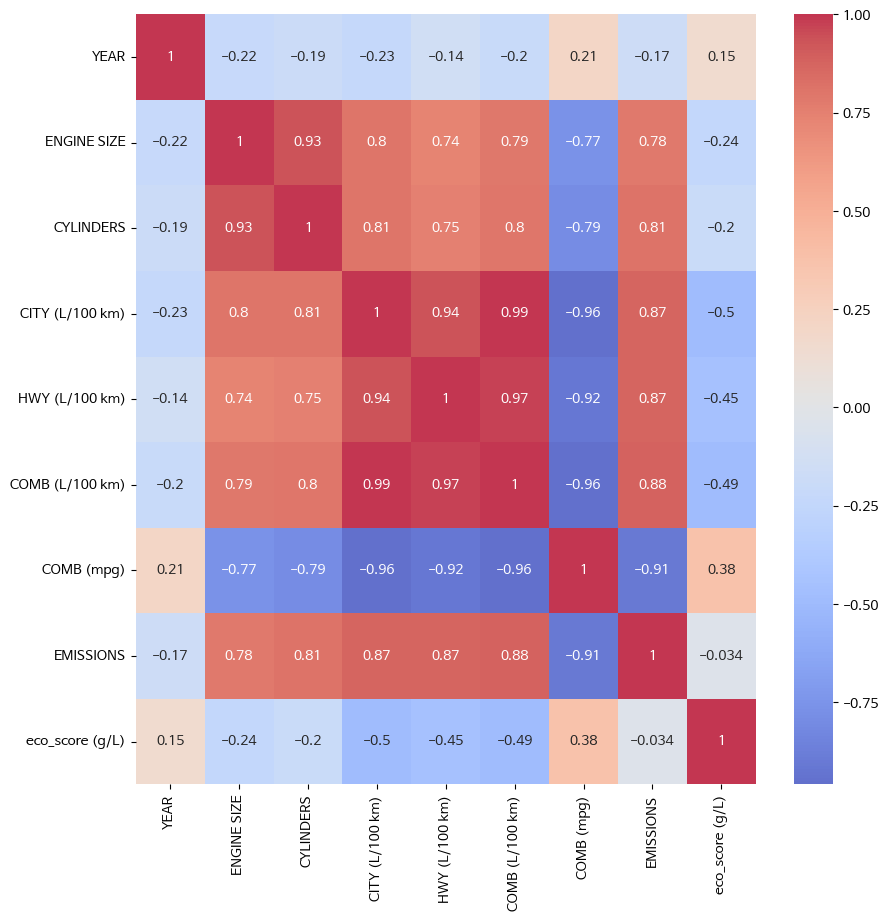

In [3]:
# (배출량 / 복합연비) 파생 변수 생성
df_suv['eco_score (g/L)'] = df_suv['EMISSIONS'] / df_suv['COMB (L/100 km)']

# 파생변수 eco_score 상관관계 확인
correlation = df_suv.corr(numeric_only=True)

plt.figure(figsize=(10,10))
sns.heatmap(correlation,annot=True,cmap='coolwarm',alpha=0.8)
plt.show()

# 상관관계가 무너지므로, 사용하지 않음

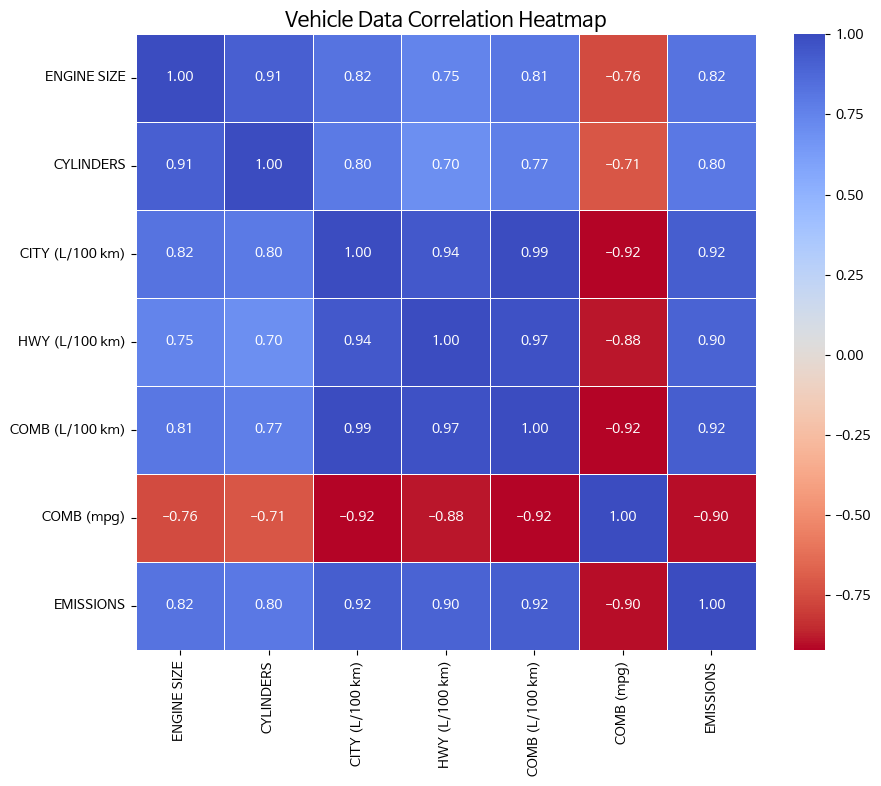

In [4]:
# 각 상관계수 확인

numeric_df = df[['ENGINE SIZE', 'CYLINDERS', 'CITY (L/100 km)',
                 'HWY (L/100 km)', 'COMB (L/100 km)', 'COMB (mpg)', 'EMISSIONS']]

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm_r', fmt=".2f", linewidths=0.5)
plt.title('Vehicle Data Correlation Heatmap', fontsize=15)
plt.show()

In [5]:
# 필요 없는 컬럼 제거
df_suv = df_suv.drop(columns = ['MAKE','MODEL', 'CITY (L/100 km)', 'HWY (L/100 km)', 'COMB (L/100 km)', 'COMB (mpg)', 'eco_score (g/L)'])
df_suv

,YEAR,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,EMISSIONS
0,2000,SUV,4.4,8,A5,Z,258
1,2000,SUV,5.7,8,A4,X,382
2,2000,SUV,4.3,6,A4,X,294
3,2000,SUV,4.3,6,M5,X,288
4,2000,SUV,4.3,6,A4,X,308
...,...,...,...,...,...,...,...
5502,2022,SUV: Small,2.0,4,A8,Z,219
5503,2022,SUV: Small,2.0,4,A8,Z,219
5504,2022,SUV: Small,2.0,4,A8,Z,232
5505,2022,SUV: Standard,2.0,4,A8,Z,236


In [6]:
# VEHICLE CLASS 의 이름을 공통적으로 변경
# 'SUV: Small'를 'SUV - SMALL', 'SUV: Standard'를 'SUV - STANDARD' 로 변경하여 이름이 같도록 변경
df_suv['VEHICLE CLASS'] = df_suv['VEHICLE CLASS'].replace({'SUV: Small': 'SUV - SMALL','SUV: Standard': 'SUV - STANDARD'}).copy()
print(df_suv['VEHICLE CLASS'].unique())

['SUV' 'SUV - STANDARD' 'SUV - SMALL']


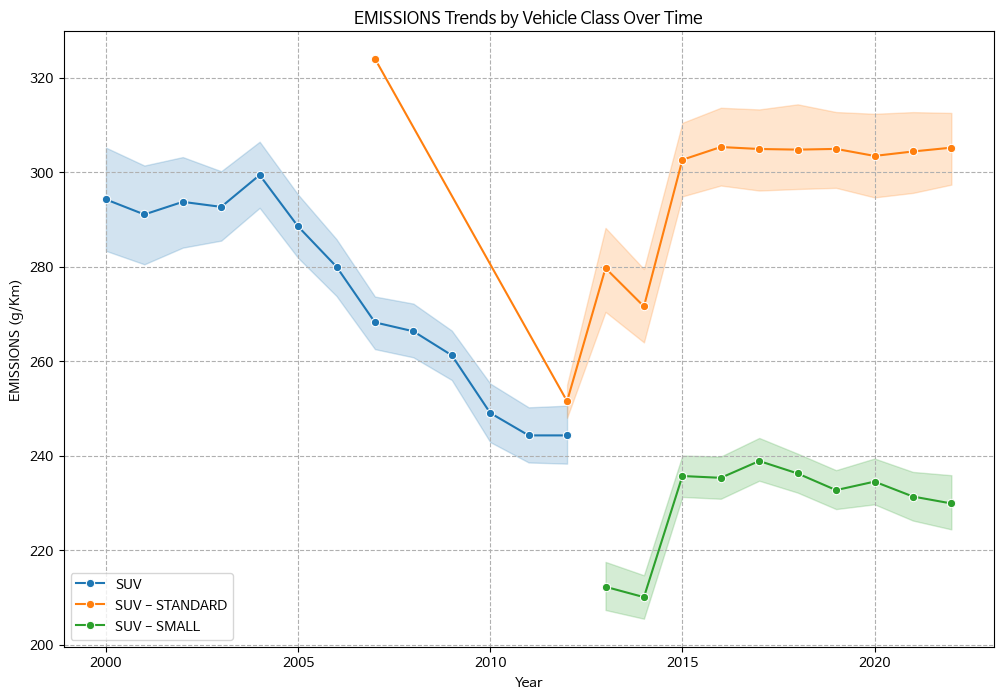

In [7]:
# 데이터 확인
plt.figure(figsize=(12, 8))
sns.lineplot(data=df_suv[df_suv['FUEL'].isin(['X', 'Z', 'D', 'E'])],
			x='YEAR', y='EMISSIONS', hue='VEHICLE CLASS', marker='o')

plt.title('EMISSIONS Trends by Vehicle Class Over Time')
plt.xlabel('Year')
plt.ylabel('EMISSIONS (g/Km)')
plt.grid(linestyle='--')
plt.legend(loc='lower left')
plt.show()

In [8]:
# 이름 바뀌기 전인 2013년 전의 SUV - STANDARD 데이터 제거
print(len(df_suv))
removed = df_suv[(df_suv['VEHICLE CLASS']=='SUV - STANDARD') & (df_suv['YEAR']<2013)].index
df_suv = df_suv.copy().drop(removed)
print(len(df_suv))

5507
5504


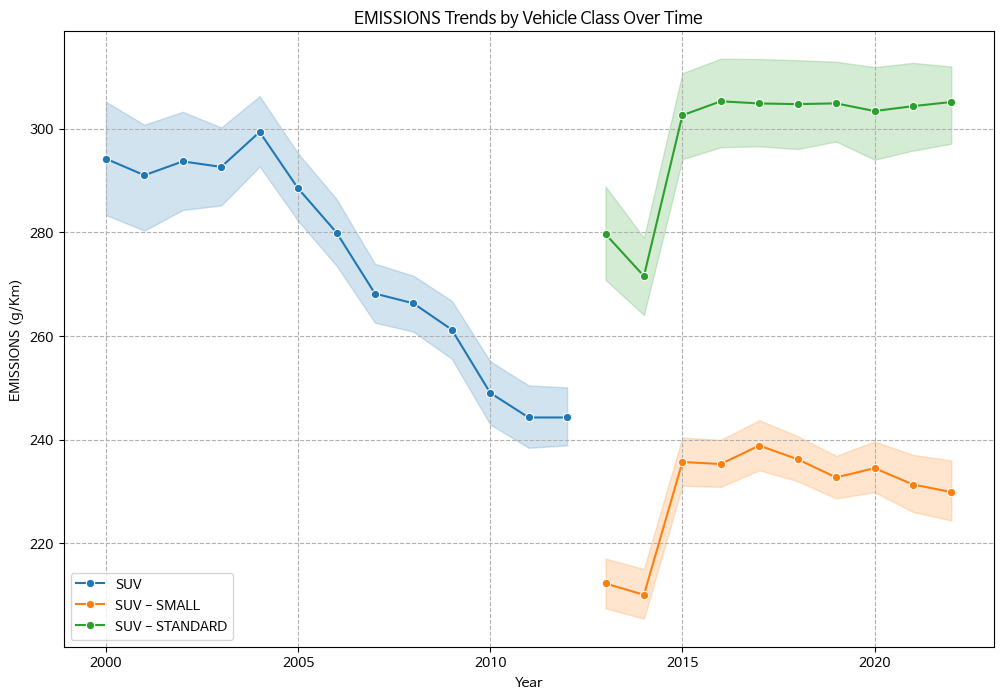

In [9]:
# 제거 후 데이터 확인
plt.figure(figsize=(12, 8))
sns.lineplot(data=df_suv[df_suv['FUEL'].isin(['X', 'Z', 'D', 'E'])],
			x='YEAR', y='EMISSIONS', hue='VEHICLE CLASS', marker='o')

plt.title('EMISSIONS Trends by Vehicle Class Over Time')
plt.xlabel('Year')
plt.ylabel('EMISSIONS (g/Km)')
plt.grid(linestyle='--')
plt.legend(loc='lower left')
plt.show()

In [10]:
# 2015년 후 배출량 데이터 15% 하향 보정
change_mask = df_suv['YEAR'] >= 2015
df_suv.loc[change_mask,'EMISSIONS'] = round(df_suv.loc[change_mask,'EMISSIONS'] * 0.85,0)
df_suv.head()

,YEAR,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,EMISSIONS
0,2000,SUV,4.4,8,A5,Z,258
1,2000,SUV,5.7,8,A4,X,382
2,2000,SUV,4.3,6,A4,X,294
3,2000,SUV,4.3,6,M5,X,288
4,2000,SUV,4.3,6,A4,X,308


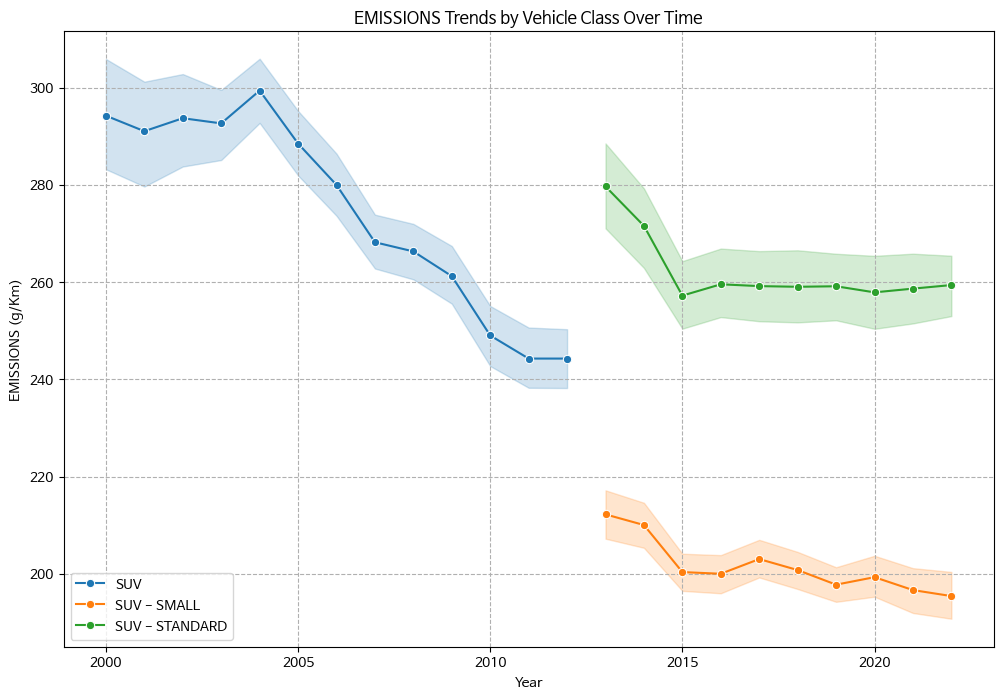

In [11]:
# 배출량 하향 보정 후 데이터 확인
plt.figure(figsize=(12, 8))
sns.lineplot(data=df_suv[df_suv['FUEL'].isin(['X', 'Z', 'D', 'E'])],
			x='YEAR', y='EMISSIONS', hue='VEHICLE CLASS', marker='o')

plt.title('EMISSIONS Trends by Vehicle Class Over Time')
plt.xlabel('Year')
plt.ylabel('EMISSIONS (g/Km)')
plt.grid(linestyle='--')
plt.legend(loc='lower left')
plt.show()

In [12]:
df_suv.head()

,YEAR,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,EMISSIONS
0,2000,SUV,4.4,8,A5,Z,258
1,2000,SUV,5.7,8,A4,X,382
2,2000,SUV,4.3,6,A4,X,294
3,2000,SUV,4.3,6,M5,X,288
4,2000,SUV,4.3,6,A4,X,308


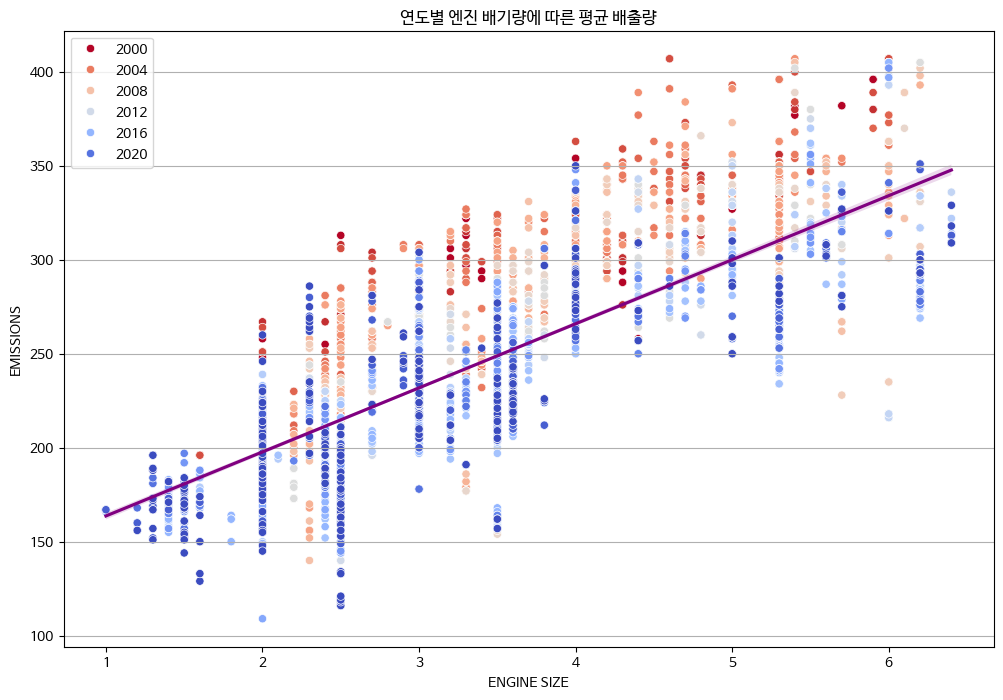

In [13]:
# 엔진 배기량에 따른 배출량

my_order = ['A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10',
            'AM6', 'AM7', 'AM8', 'AV', 'AV6', 'AV7', 'AV8', 'AV10',
            'M5', 'M6', 'M7']

plt.figure(figsize=(12, 8))
sns.scatterplot(data = df_suv, x='ENGINE SIZE', y='EMISSIONS', hue='YEAR', palette='coolwarm_r')
sns.regplot(data = df_suv, x='ENGINE SIZE', y='EMISSIONS', color='purple', scatter=False)
plt.legend(loc='upper left')
plt.title('연도별 엔진 배기량에 따른 평균 배출량')
plt.grid(axis='y')
plt.show()

/tmp/ipykernel_9398/3334386427.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_suv, x='CYLINDERS', y='EMISSIONS', palette='coolwarm')


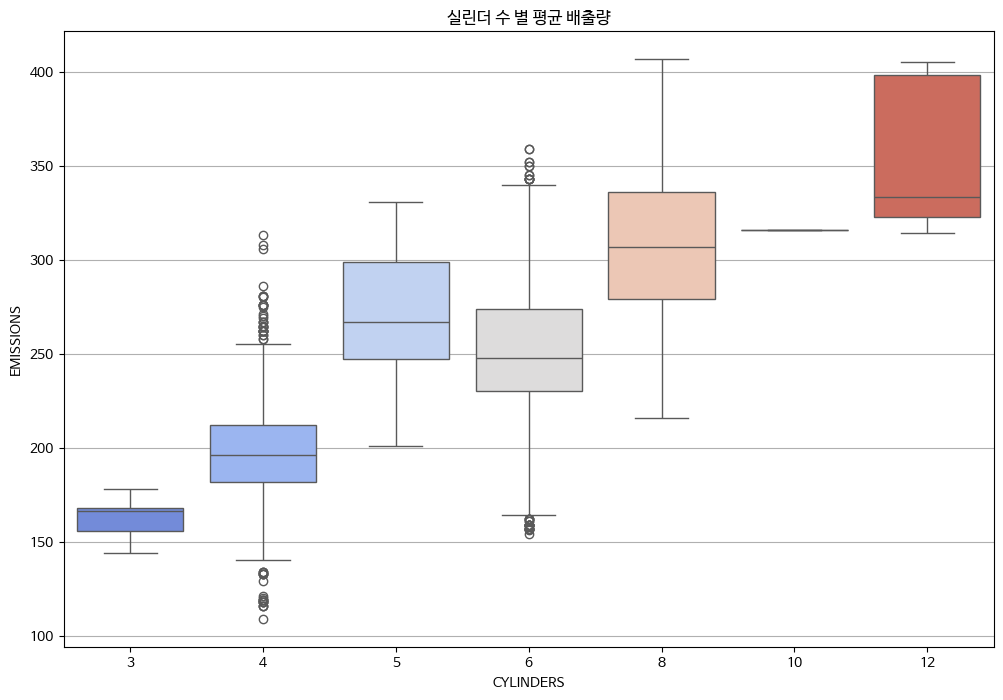

In [14]:
# 실린더 개수에 따른 배출량

plt.figure(figsize=(12, 8))
sns.boxplot(data = df_suv, x='CYLINDERS', y='EMISSIONS', palette='coolwarm')
plt.title('실린더 수 별 평균 배출량')
plt.grid(axis='y')
plt.show()

/tmp/ipykernel_9398/3393030197.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_suv, x='TRANSMISSION', y='EMISSIONS', errorbar=None, order=my_order, palette='coolwarm')


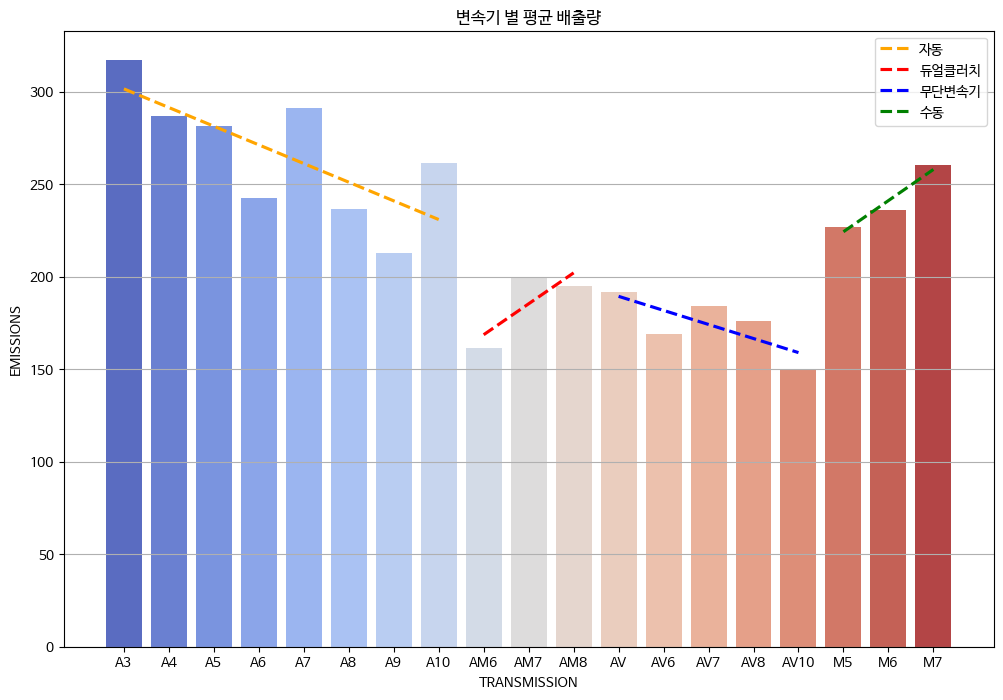

In [15]:
# 변속기 별 평균 배출량

import matplotlib.colors as mcolors
my_order = ['A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10',
            'AM6', 'AM7', 'AM8', 'AV', 'AV6', 'AV7', 'AV8', 'AV10',
            'M5', 'M6', 'M7']
groups = {
    '자동': ['A3','A4','A5','A6','A7','A8','A9','A10'],
    '듀얼클러치': ['AM6','AM7','AM8'],
    '무단변속기': ['AV','AV6','AV7','AV8','AV10'],
    '수동': ['M5','M6','M7']
}
colors = {'자동':'orange', '듀얼클러치':'red', '무단변속기':'blue', '수동':'green'}

plt.figure(figsize=(12, 8))
sns.barplot(data = df_suv, x='TRANSMISSION', y='EMISSIONS', errorbar=None, order=my_order, palette='coolwarm')

pos_map = {name: i for i, name in enumerate(my_order)}
for group_name, members in groups.items():
    x_vals, y_vals = [], []
    for m in members:
        if m in df_suv['TRANSMISSION'].values:
            mean_val = df_suv[df_suv['TRANSMISSION'] == m]['EMISSIONS'].mean()
            x_vals.append(pos_map[m])
            y_vals.append(mean_val)

    sns.regplot(x=np.array(x_vals), y=np.array(y_vals),
                color=colors[group_name], scatter=False,ci=None,
                label=group_name,line_kws={'linestyle':'--'})

plt.legend(loc='best')
plt.title('변속기 별 평균 배출량')
plt.grid(axis='y')
plt.show()

In [16]:
# 분산분석을 진행한 R 코드


# > data<-read.csv("C:/Users/차량_연비_데이터(20022022)_v2.csv")
# > data <- unique(data)
# > model <- aov(EMISSIONS~VEHICLE.CLASS+ENGINE.SIZE+CYLINDERS+TRANSMISSION+FUEL+YEAR,data)
# > summary(model)